In [ ]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
# import pandas_ta
# import talib

# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *
from pklib.pkindicators import calculate_zigzag


import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline


In [ ]:
def skip_first_fn(params):
    skip_first = max(params['tenkan_period'], params['kijun_period'], params['senkou_span_b_period']) + params['chikou_span_delay']
    return skip_first


def calculate_ichimoku(data, params):
    tenkan_period = params['tenkan_period']
    kijun_period = params['kijun_period']
    senkou_span_b_period = params['senkou_span_b_period']
    chikou_span_delay = params['chikou_span_delay']
    
    data['tenkan_ema'] = data.close.ewm(span=tenkan_period, adjust=False).mean()
    data['kijun_ema'] = data.close.ewm(span=kijun_period, adjust=False).mean()
    data['senkou_ema'] = data.close.ewm(span=senkou_span_b_period, adjust=False).mean()

    # Tenkan-sen (Conversion Line)
    data['tenkan_sen'] = (data['close'].rolling(window=tenkan_period).max() + 
                          data['close'].rolling(window=tenkan_period).min()) / 2

    # Kijun-sen (Base Line)
    data['kijun_sen'] = (data['close'].rolling(window=kijun_period).max() + 
                         data['close'].rolling(window=kijun_period).min()) / 2

    # Senkou Span A (Leading Span A)
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(chikou_span_delay)

    # Senkou Span B (Leading Span B)
    data['senkou_span_b'] = ((data['close'].rolling(window=senkou_span_b_period).max() + 
                              data['close'].rolling(window=senkou_span_b_period).min()) / 2).shift(chikou_span_delay)

    # Chikou Span (Lagging Span)
    # data['chikou_span'] = data['close'].shift(-chikou_span_delay)
    
    # data['cloud_upper'] = data[['senkou_span_a', 'senkou_span_b']].max(axis=1)
    # data['cloud_lower'] = data[['senkou_span_a', 'senkou_span_b']].min(axis=1)
    
    # data['close_above_cloud'] = data['close'] > data['cloud_upper']
    # data['close_below_cloud'] = data['close'] < data['cloud_lower']
    
    # data['full_bull'] = (
    #     (data['tenkan_sen'] > data['kijun_sen']) &
    #     (data['close_above_cloud']))
    
    # data['full_bear'] = (
    #     (data['tenkan_sen'] < data['kijun_sen']) &
    #     (data['close_below_cloud']))
    

In [ ]:
# fib_levels = np.array([-1.0, -0.786, -0.618, -0.5, -0.382, -0.236, 0.0, 0.236, 0.382, 0.5, 0.618, 0.786, 1.0, 1.236, 1.5, 1.618, 1.786, 2.0, 2.236, 2.382, 2.5, 2.628, 2.786, 3, 3.382, 3.618, 4, 5])
fib_levels = np.array([-1.0, -0.618, -0.236, 0.0, 0.236, 0.5, 0.618, 0.786, 1.0, 1.236, 1.618, 2.0, 2.5, 3, 4, 5])

fib_columns = [f'fib({fib})' for fib in fib_levels]
# fib_columns 

def calculate_fib_levels(highs, lows, directions, fib_levels=fib_levels):
    # Ensure highs, lows, and directions are numpy arrays
    highs = np.asarray(highs)
    lows = np.asarray(lows)
    directions = np.asarray(directions)

    # Flip highs and lows based on direction (-1 means flip)
    adjusted_highs = np.where(directions == 1, highs, lows)
    adjusted_lows = np.where(directions == 1, lows, highs)

    # Calculate the difference between adjusted high and low
    diff = adjusted_highs - adjusted_lows

    # Calculate the Fibonacci levels by applying the levels to the differences
    fib_matrix = np.outer(diff, fib_levels)
    
    # Calculate the actual levels by adding them to the low (base) level
    fib_levels_array = adjusted_lows[:, np.newaxis] + fib_matrix

    return fib_levels_array


In [ ]:
epsilon = 0.2

def get_fib_data(asset, quote, timeframe, exchange):
    # asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
    data = load_candles('binance',asset, quote, timeframe)#['2020':'2024']#.iloc[-35000:-5000]
        
    # Call the calculate_zigzag function from the C module
    high_low_markers, turning_points = calculate_zigzag(data['close'].values, epsilon=epsilon)

    # Store the results back into the DataFrame for easier plotting
    # data['HighLowMarkers'] = high_low_markers
    # data['TurningPoints'] = turning_points

    # Get the indices of highs and lows
    # highs_idx = data.index[data['HighLowMarkers'] == 1]
    # lows_idx = data.index[data['HighLowMarkers'] == -1]
    highs_idx = data.index[high_low_markers == 1]
    lows_idx = data.index[turning_points == -1]

    running_highs = (np.where(high_low_markers == 1, 1, np.nan) * data['close']).ffill()
    running_lows = (np.where(high_low_markers == -1, 1, np.nan) * data['close']).ffill()


    running_highs_idx = pd.Series(np.where(high_low_markers == 1, 1, np.nan) * np.arange(len(data))).set_axis(data.index).ffill()
    running_lows_idx = pd.Series(np.where(high_low_markers == -1, 1, np.nan) * np.arange(len(data))).set_axis(data.index).ffill()

    # Combine the indices and sort them
    turning_points_idx = sorted(highs_idx.union(lows_idx))

    # Assuming calculate_fib_levels is defined elsewhere in your code
    fibs = calculate_fib_levels(running_lows, running_highs, ((running_highs_idx > running_lows_idx) * 2 - 1))

    df_fibs = data.join(pd.DataFrame(fibs, columns=fib_columns, index=data.index))
    return df_fibs.dropna()


asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)
data

In [ ]:
df_fibs#.shape

In [ ]:

asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
def get_ichi_data(asset, quote, timeframe, exchange, params):
    data = load_candles('binance',asset, quote, timeframe)#['2020':'2024']#.iloc[-35000:-5000]
    # params = {'tenkan_period': 20, 'kijun_period': 60, 'senkou_span_b_period': 120, 'chikou_span_delay': 30}
    calculate_ichimoku(data, params)
    skip_first = skip_first_fn(params)
    data = data.iloc[skip_first:]
    return data
# data = get_data('ADA', 'USDT', '8h', 'binance')
# data

In [ ]:


params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
data = get_data('BTC', 'USDT', '4h', 'binance', params)

In [115]:

# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs,_ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, and cumulative PnL
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(env.cumulative_pnl)
        price_log.append(env.df['close'].iloc[env.current_step])

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': price_log,
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)        
    }, index=env.df.index[lookback_window_size+1:])


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.3)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


In [ ]:
import numpy as np
import pandas as pd
from collections import deque
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

class TradingEnv(gym.Env):
    def __init__(self, df, lookback_window_size=10):
        super(TradingEnv, self).__init__()
        
        self.df = df
        self.lookback_window_size = lookback_window_size
        
        self.current_step = 0
        self.entry_price = None
        self.cumulative_pnl = 0
        self.position = 0  # 1 = long, 0 = no position, -1 = short

        # Define action space: 0 = hold, 1 = long, 2 = short, 3 = close position
        self.action_space = spaces.Discrete(4)

        # Observation space: OHLCV + technical indicators + entry price + position (flattened lookback period + 2 additional features)
        obs_space_shape = (lookback_window_size * len(self.df.columns) + 2,)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)

        # A buffer to hold the lookback window of observations
        self.history = deque(maxlen=self.lookback_window_size)

    def reset(self, seed=None, options=None):
        self.current_step = self.lookback_window_size  # Start after enough steps for lookback
        self.entry_price = None
        self.cumulative_pnl = 0
        self.position = 0  # Reset position

        # Clear the history buffer and fill it with the initial lookback window
        self.history.clear()

        # Initialize the buffer with the lookback window of observations for the starting point
        start_index = max(0, self.current_step - self.lookback_window_size)
        initial_observation = self.df.iloc[start_index:self.current_step].values

        # Pad the history if there are fewer observations than the lookback size
        if len(initial_observation) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(initial_observation), len(self.df.columns)))
            initial_observation = np.vstack((padding, initial_observation))
        
        self.history.append(initial_observation)

        # Return the initial flattened observation (1D array) with position and entry price
        return np.hstack([initial_observation.flatten(), [self.position, self.entry_price if self.entry_price else 0]]).astype(np.float32), {'cumulative_pnl': 0}

    def step(self, action):
        current_price = self.df['close'].iloc[self.current_step]
        reward = 0
        pnl = 0

        if action == 1:  # Open or maintain long
            if self.position == -1:  # Close short
                pnl = self.position * np.log(self.entry_price / current_price)
                self.cumulative_pnl += pnl

            self.entry_price = current_price  # New long entry
            self.position = 1  # Set position to long

        elif action == 2:  # Open or maintain short
            if self.position == 1:  # Close long
                pnl = self.position * np.log(current_price / self.entry_price)
                self.cumulative_pnl += pnl

            self.entry_price = current_price
            self.position = -1  # Set position to short

        elif action == 3 and self.position != 0:  # Close position
            pnl = self.position * np.log(current_price / self.entry_price)
            self.cumulative_pnl += pnl
            self.position = 0  # No position

        # Move to the next step
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1  # Terminate if we reached the end of the data
        truncated = False  # You can set this based on some condition like max steps, if needed

        reward = np.expm1(pnl)#*30
        # reward = self.cumulative_pnl
        # if terminated:
        #     reward = self.cumulative_pnl
        if reward < 0 : 
            reward = 100 * reward
        # if pnl < np.log(0.5):
        #     reward = -10
        # else:
        #     reward = np.sign(pnl)*np.exp(pnl)
        # Get next observation
        obs = self._next_observation()

        return obs, reward, terminated, truncated, {'cumulative_pnl': self.cumulative_pnl}

    def _next_observation(self):
        # Handle edge cases where the current step is less than the lookback window size
        start_index = max(0, self.current_step - self.lookback_window_size)
        frame = self.df.iloc[start_index:self.current_step]

        # If the lookback window is smaller than the full lookback size, pad with earlier rows
        if len(frame) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(frame), len(self.df.columns)))
            frame = np.vstack((padding, frame.values))
        else:
            frame = frame.values

        # Return flattened lookback window and append position and entry price
        return np.hstack([frame.flatten(), [self.position, self.entry_price if self.entry_price else 0]]).astype(np.float32)

    def render(self):
        current_price = self.df['close'].iloc[self.current_step]
        position_str = "Long" if self.position == 1 else ("Short" if self.position == -1 else "No position")
        print(f"Step: {self.current_step}, Price: {current_price:.2f}, Position: {position_str}, Entry Price: {self.entry_price if self.entry_price else 'N/A'}, Cumulative PnL: {self.cumulative_pnl:.2f}")


In [ ]:
from sb3_contrib import RecurrentPPO
from sb3_contrib.common.recurrent.policies import RecurrentActorCriticPolicy
import torch as th
import torch.nn as nn

# Custom LSTM policy class
class CustomLstmPolicy(RecurrentActorCriticPolicy):
    def __init__(self, observation_space, action_space, lr_schedule, lstm_hidden_size=256, lstm_hidden_size_va=None, **kwargs):
        super(CustomLstmPolicy, self).__init__(observation_space, action_space, lr_schedule, **kwargs)
        
        if lstm_hidden_size_va is None:
            lstm_hidden_size_va = lstm_hidden_size

        self.lstm_hidden_size = lstm_hidden_size
        self.lstm_hidden_size_va = lstm_hidden_size_va
        self.lstm_actor = nn.LSTM(self.features_dim, self.lstm_hidden_size, batch_first=True)
        self.lstm_critic = nn.LSTM(self.features_dim, self.lstm_hidden_size_va, batch_first=True)

        # Fully connected layers after LSTM
        self.fc_policy = nn.Sequential(
            nn.Linear(self.lstm_hidden_size, 128),
            nn.ReLU(),
            nn.Linear(128, self.action_space.n)
        )

        self.fc_value = nn.Sequential(
            nn.Linear(self.lstm_hidden_size_va, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, obs, lstm_states, dones):
        # Process observation and reshape for LSTM
        obs = obs.unsqueeze(1)  #


In [107]:
from stable_baselines3 import PPO, A2C, DDPG, DQN, SAC
import pandas as pd
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from sb3_contrib import RecurrentPPO

num_cpu = os.cpu_count()

# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('BTC', 'USDT', '12h', 'binance', params)

asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange).astype('Float32')
df = data.iloc[:data.shape[0]//2]#.copy()
# df = data

# Initialize the environment
env = TradingEnv(df, lookback_window_size=10)
env = make_vec_env( lambda: TradingEnv(df, lookback_window_size=10),n_envs=num_cpu,seed=0,vec_env_cls=DummyVecEnv)
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)
# check_env(env, warn=True, skip_render_check=True)

# policy_kwargs = dict(
#     net_arch=[dict(pi=[64,64,64,32], vf=[64,64,64,32])]  # Smaller network
# )

# model = PPO('MlpPolicy', env, policy_kwargs=policy_kwargs, verbose=1, gamma=0.98)

# Initialize the PPO model with the MLP policy
# model = A2C("MlpPolicy", env, verbose=1 , policy_kwargs=policy_kwargs)
model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0008)
# model = DQN("MlpPolicy", env, verbose=2, learning_rate=0.0001 )
# env = make_vec_env(lambda: TradingEnv(df, lookback_window_size=10), n_envs=4)

# model = RecurrentPPO(CustomLstmPolicy, env, verbose=1, learning_rate=0.0006, policy_kwargs={"lstm_hidden_size": 212, "lstm_hidden_size_va": 212})



# Use RecurrentPPO with the LstmPolicy
# model = RecurrentPPO("MlpLstmPolicy", env, verbose=1)


# Train the model
model.learn(total_timesteps=100000)

# Save the trained model
model.save("ppo_trading_model")



------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 3.83e+03     |
|    ep_rew_mean          | -1.01e+03    |
| time/                   |              |
|    fps                  | 1417         |
|    iterations           | 3            |
|    time_elapsed         | 86           |
|    total_timesteps      | 122880       |
| train/                  |              |
|    approx_kl            | 0.0092579145 |
|    clip_fraction        | 0.103        |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.36        |
|    explained_variance   | 0.785        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0089       |
|    n_updates            | 20           |
|    policy_gradient_loss | -0.00406     |
|    value_loss           | 0.0747       |
------------------------------------------


                        Price Action  Position       PnL
timestamp                                               
2017-08-21 08:00:00   4022.00      0         0  0.000000
2017-08-21 16:00:00   4016.00      0         0  0.000000
2017-08-22 00:00:00   3798.08      0         0  0.000000
2017-08-22 08:00:00   3858.23      3         0  0.000000
2017-08-22 16:00:00   4040.00      0         0  0.000000
...                       ...    ...       ...       ...
2024-08-22 00:00:00  60984.31      3         0  3.195431
2024-08-22 08:00:00  60407.40      2        -1  3.195431
2024-08-22 16:00:00  60375.84      1         1  3.155743
2024-08-23 00:00:00  61069.27      1         1  3.155743
2024-08-23 08:00:00  61533.05      0         1  3.155743

[7675 rows x 4 columns]


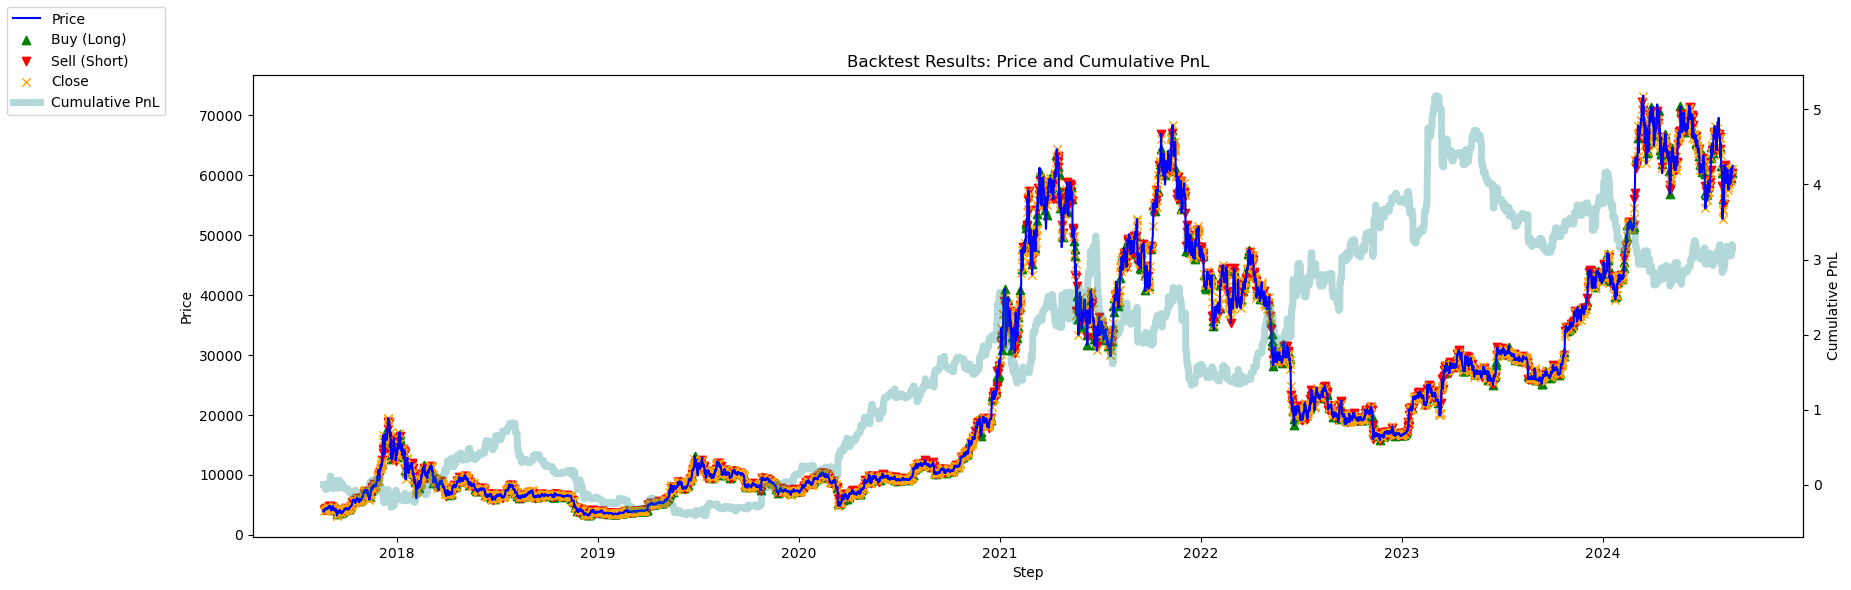

In [118]:
asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)

# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('BTC', 'USDT', '8h', 'binance', params)
lookback_window_size=10
# env = TradingEnv(data, lookback_window_size=lookback_window_size)
env = TradingEnv(data, lookback_window_size=10)
# env = make_vec_env( lambda: TradingEnv(data, lookback_window_size=10),n_envs=num_cpu,seed=0,vec_env_cls=DummyVecEnv)
# env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

        
# env.reset().shape
# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)

In [ ]:
asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)

# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('ADA', 'USDT', '8h', 'binance', params)
# Initialize the environment
lookback_window_size=10
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:


# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('BTC', 'USDT', '12h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)

# Initialize the environment
lookback_window_size=10
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:

# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# df = get_data('SOL', 'USDT', '4h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '4h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)
# Initialize the environment
lookback_window_size=10
env = TradingEnv(df, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:
import matplotlib.pyplot as plt

# Plot the price, cumulative log-return PnL, and buy/sell signals
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the closing price on the primary y-axis
ax1.plot(env.df.index, env.df['close'], label='Close Price', color='blue', lw=2)

# Plot entry (buy) and exit (sell) signals as vertical lines
for idx, row in tracking_df.iterrows():
    if row['action'] == 2:  # Buy signal
        ax1.axvline(x=idx, color='green', linestyle='--', lw=1, label='Buy')
    elif row['action'] == 0:  # Sell signal
        ax1.axvline(x=idx, color='red', linestyle='--', lw=1, label='Sell')

# Create a secondary y-axis for cumulative log-return PnL
ax2 = ax1.twinx()
ax2.plot(tracking_df.index, tracking_df['cumulative_pnl'], label='Cumulative PnL (Log Returns)', color='black', lw=1.5, linestyle='--')
ax2.set_ylabel('Cumulative PnL (Log Returns)')

# Set labels and title
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.set_title('Agent Trading Performance: Price, Entry/Exit, and Cumulative PnL (Log Returns)')

plt.show()
